<a href="https://colab.research.google.com/github/Feliz-ua/goit-np-hw-08/blob/main/np-hw-08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from numpy.linalg import inv, det
from matplotlib.colors import ListedColormap

In [3]:
# 1. Завантажуємо набір даних
iris = load_iris()
X, y= iris.data, iris.target
target_names = iris.target_names
feature_names = iris.feature_names

In [4]:
# 2. Розподіляємо дані на навчальні та тестові
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# 3. Використати вибірку ознак окремо для кожного класа.
x_0 = X_train[y_train == 0]
x_1 = X_train[y_train == 1]
x_2 = X_train[y_train == 2]

# Додатково: Розрахунок середніх значень (центрів класів)
mean_0 = np.mean(x_0, axis=0)
mean_1 = np.mean(x_1, axis=0)
mean_2 = np.mean(x_2, axis=0)

print("Середні значення ознак (центри класів):")
for i, m in enumerate([mean_0, mean_1, mean_2]):
    print(f"Клас {i} ({target_names[i]}): {m}")
print("\n" + "-"*50 + "\n")


Середні значення ознак (центри класів)
Клас 0 (setosa): [4.99   3.4525 1.45   0.245 ]
Клас 1 (versicolor): [5.9195 2.7707 4.2415 1.322 ]
Клас 2 (virginica): [6.5333 2.9667 5.5205 2.    ]

--------------------------------------------------



In [27]:
# 4. Розрахунок матриць коваріації для набору ознак кожного класа.
cov_0 = np.cov(x_0.T)
cov_1 = np.cov(x_1.T)
cov_2 = np.cov(x_2.T)

print("4. Матриці коваріації:\n")
for i, (c, name) in enumerate(zip([cov_0, cov_1, cov_2], target_names)):
    print(f"Матриця класу {i} ({name}):")
    print(c)
    print(f"Визначник (Determinant): {det(c):.6f}")
    print("-" * 45)
print("\n" + "="*50 + "\n")

4. Матриці коваріації

Матриця класу 0 (setosa):
[[0.1271 0.108  0.019  0.0094]
 [0.108  0.1564 0.0137 0.0081]
 [0.019  0.0137 0.0338 0.0067]
 [0.0094 0.0081 0.0067 0.0113]]
Визначник (Determinant): 0.000002
---------------------------------------------
Матриця класу 1 (versicolor):
[[0.2941 0.1011 0.1959 0.0606]
 [0.1011 0.1026 0.0962 0.0472]
 [0.1959 0.0962 0.2315 0.0813]
 [0.0606 0.0472 0.0813 0.0423]]
Визначник (Determinant): 0.000017
---------------------------------------------
Матриця класу 2 (virginica):
[[0.4275 0.1011 0.3143 0.0495]
 [0.1011 0.1018 0.0928 0.0603]
 [0.3143 0.0928 0.2933 0.0521]
 [0.0495 0.0603 0.0521 0.0842]]
Визначник (Determinant): 0.000092
---------------------------------------------




In [29]:
# 5.Розрахунок обернених матриць коваріації
inv_cov_0 = inv(cov_0)
inv_cov_1 = inv(cov_1)
inv_cov_2 = inv(cov_2)

print("5. Обернені матриці коваріації\n")
for i, (ic, name) in enumerate(zip([inv_cov_0, inv_cov_1, inv_cov_2], target_names)):
    print(f"Обернена матриця класу {i} ({name}):")
    print(ic)
    print("-" * 45)


5. Обернені матриці коваріації

Обернена матриця класу 0 (setosa):
[[ 20.28   -13.3253  -5.1012  -4.4023]
 [-13.3253  15.5158   1.3334  -0.7704]
 [ -5.1012   1.3334  35.3331 -17.6083]
 [ -4.4023  -0.7704 -17.6083 103.5108]]
---------------------------------------------
Обернена матриця класу 1 (versicolor):
[[  9.2722  -5.1765  -9.4341  10.643 ]
 [ -5.1765  23.0553   3.7901 -25.6048]
 [ -9.4341   3.7901  23.0398 -35.0465]
 [ 10.643  -25.6048 -35.0465 104.4303]]
---------------------------------------------
Обернена матриця класу 2 (virginica):
[[ 11.1699  -1.2868 -11.8665   1.7009]
 [ -1.2868  21.507   -3.1761 -12.6697]
 [-11.8665  -3.1761  17.4042  -1.5243]
 [  1.7009 -12.6697  -1.5243  20.8857]]
---------------------------------------------


In [30]:
# 6. Обчислюємо апріорні імовірності кожного класа у тренувальних даних.
P_0 = len(x_0) / len(X_train)
P_1 = len(x_1) / len(X_train)
P_2 = len(x_2) / len(X_train)
print(f"Апріорні ймовірності: P0={P_0:.2f}, P1={P_1:.2f}, P2={P_2:.2f}")

Апріорні ймовірності: P0=0.33, P1=0.34, P2=0.33


In [31]:
# 7. Функція обчислення дискримінантної функції для одного рядка а імовірностей приналежності кожному класу для всієї матриці тестових даних
def g(x_test, X_class, X_cov, X_inv_cov, X_prob):
    # Розрахунок детермінанти та середнього
    cov_det = det(X_cov)
    log_cov_det = np.log(cov_det)
    x_mean = np.mean(X_class, axis=0).reshape(-1, 1)

    diff = x_test.reshape(-1, 1) - x_mean
    # Формула: g_i(x) = -1/2 * (x-mu)^T * Sigma^-1 * (x-mu) - 1/2 * ln|Sigma| + ln(P)
    g_i = -0.5 * diff.T @ X_inv_cov @ diff - 0.5 * log_cov_det + np.log(X_prob)
    return g_i

In [34]:
# 8. Реалізувати функцію обчислення значень дискримінантної функції та імовірностей приналежності кожному класу для всієї матриці тестових даних.
def g_matrix(X_test_mat, classes_data, covs, inv_covs, probs):
    g_val = []
    g_proba = []
    for i in range(len(X_test_mat)):
        x_single = X_test_mat[i]

        # Обчислення g для кожного з 3-х класів
        g0 = g(x_single, classes_data[0], covs[0], inv_covs[0], probs[0])
        g1 = g(x_single, classes_data[1], covs[1], inv_covs[1], probs[1])
        g2 = g(x_single, classes_data[2], covs[2], inv_covs[2], probs[2])

        g_i = np.array([g0[0][0], g1[0][0], g2[0][0]])

        # Розрахунок ймовірностей (Softmax)
        likelihood = np.exp(g_i - np.max(g_i))
        res = likelihood / np.sum(likelihood)

        g_val.append(g_i)
        g_proba.append(res)
    return np.array(g_val), np.array(g_proba)

# Виклик власної функції
g_val_own, g_prob_own = g_matrix(
    X_test,
    [x_0, x_1, x_2],
    [cov_0, cov_1, cov_2],
    [inv_cov_0, inv_cov_1, inv_cov_2],
    [P_0, P_1, P_2]
)
print(f"Власні ймовірності для першого тестового зразка: {g_prob_own[0]}")

Власні ймовірності для першого тестового зразка: [0.     0.9713 0.0287]


In [35]:
# 9. Виконати прогнозування на тестових даних за допомогою функії QuadraticDiscriminantAnalysis() бібліотеки sklearn та порівняти отримані результати.
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
values_qda = qda.decision_function(X_test)
proba_qda = qda.predict_proba(X_test)

# Формування таблиці порівняння
dataframe = pd.DataFrame({
    "g0_own": g_val_own[:,0], "g0_sklearn": values_qda[:,0],
    "P0_own": g_prob_own[:,0], "P0_sklearn": proba_qda[:,0],
    "Class_own": np.argmax(g_prob_own, axis=1),
    "Class_sklearn": qda.predict(X_test)
})

print("\nТаблиця порівняння (Власна функція vs Sklearn):")
display(dataframe.head())



Таблиця порівняння (Власна функція vs Sklearn):


,g0_own,g0_sklearn,P0_own,P0_sklearn,Class_own,Class_sklearn
0,-173.824135,-173.824135,3.138350e-76,3.138350e-76,1,1
1,2.557071,2.557071,1.000000e+00,1.000000e+00,0,0
2,-546.924689,-546.924689,5.078498e-235,5.078498e-235,2,2
3,-170.239537,-170.239537,2.249533e-76,2.249533e-76,1,1
4,-203.606667,-203.606667,3.180059e-90,3.180059e-90,1,1


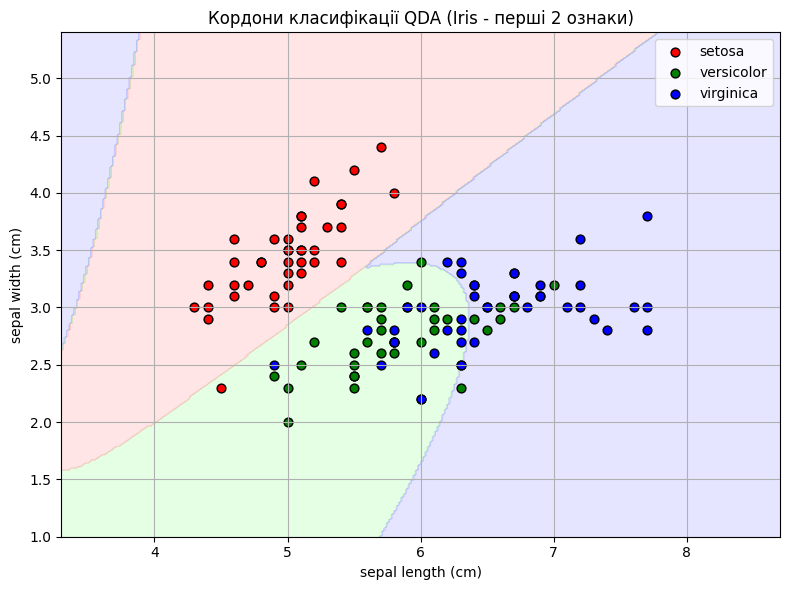

In [11]:
# Візуалізація
X_vis = X_train[:, :2] # Використовуємо перші 2 ознаки для 2D графіка
y_vis = y_train

qda_vis = QuadraticDiscriminantAnalysis()
qda_vis.fit(X_vis, y_vis)

x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

Z = qda_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

colors = ['red', 'green', 'blue']
for idx, color in enumerate(colors):
    plt.scatter(X_vis[y_vis == idx, 0], X_vis[y_vis == idx, 1],
                label=f'{target_names[idx]}', edgecolor='k', s=40, color=color)

plt.title("Кордони класифікації QDA (Iris - перші 2 ознаки)")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
accuracy = np.mean(dataframe['Class_own'] == dataframe['Class_sklearn'])
print(f"\nСтупінь схожості прогнозів: {accuracy * 100:.2f}%")
print("Власна реалізація та бібліотека sklearn дали ідентичні результати класифікації.")


Ступінь схожості прогнозів: 100.00%
Власна реалізація та бібліотека sklearn дали ідентичні результати класифікації.


### **Висновки:**
1. На графіку "Кордони класифікації QDA" ми бачимо роботу моделі на перших двох ознаках (довжина та ширина чашолистка):

- Криволінійні кордони: на відміну від лінійного аналізу (LDA), тут межі між класами у формі параболи або гіперболи. Це прямий результат використання різних матриць коваріації.

- Клас Setosa (червоний): Модель ідеально відокремила цей клас. Видно, що червона зона чітко охоплює групу точок, оскільки вони мають низьку дисперсію.

- Зона перекриття (Versicolor vs Virginica): Зелені та сині точки знаходяться досить близько одна до одної. Можна помітити, що один синій маркер потрапив у зелену зону, а декілька зелених — у синю. Це пояснює, чому точність класифікації на цих ознаках не є 100%.

2. Візуалізація довела, що QDA є більш гнучким інструментом, ніж лінійні моделі, оскільки дозволяє будувати складні вигнуті межі, що краще адаптуються до реальної форми даних кожного класу.

3. Результати написаного алгоритму повністю співпадають з результатами роботи бібліотеки $sklearn$.
   
